# Model Training — Telco Customer Churn

Trains and compares churn-prediction models on the preprocessed data from `02_preprocessing.ipynb`, tunes the best candidate, and evaluates it on the held-out test set.

`xgboost`/`lightgbm` aren't installed in this environment (they're behind the optional `ml` extra in `pyproject.toml`), so this notebook sticks to scikit-learn models — Logistic Regression, Random Forest, and Gradient Boosting.

## 1. Setup & Load Processed Data

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

sns.set_theme(style="whitegrid")

DATA_DIR = Path.cwd().resolve().parent / "data" / "processed"
MODELS_DIR = Path.cwd().resolve().parent / "models"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print("train:", train.shape, "| test:", test.shape)
train.head()

train: (5634, 25) | test: (1409, 25)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,1,0,0,0,0.102371,0,0,0,0,1,...,-0.521976,-0.262257,1,0,0,0,0,1,0,0
1,1,0,1,1,-0.711743,1,0,1,0,0,...,0.337478,-0.503635,0,1,0,0,0,0,1,0
2,1,0,1,1,-0.793155,0,0,1,1,0,...,-0.809013,-0.749883,1,0,0,0,0,0,1,0
3,0,0,1,0,-0.263980,1,0,0,1,1,...,0.284384,-0.172722,1,0,0,0,1,0,0,0
4,1,0,1,1,-1.281624,1,0,0,0,0,...,-0.676279,-0.989374,1,0,0,0,0,1,0,0


## 2. Prepare Features & Target

In [2]:
X_train = train.drop(columns=["Churn"])
y_train = train["Churn"]
X_test = test.drop(columns=["Churn"])
y_test = test["Churn"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.4f} | Test churn rate: {y_test.mean():.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train: (5634, 24), X_test: (1409, 24)
Train churn rate: 0.2654 | Test churn rate: 0.2654


## 3. Baseline Model — Logistic Regression

`class_weight="balanced"` compensates for the ~27% positive class rate.

In [3]:
baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, baseline_pred, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, baseline_proba):.4f}")

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8419


## 4. Baseline Confusion Matrix

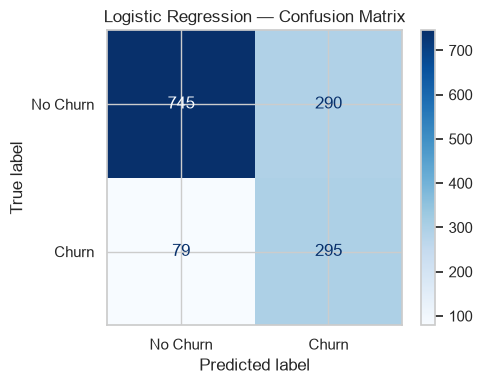

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, baseline_pred, display_labels=["No Churn", "Churn"], cmap="Blues", ax=ax
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 5. Compare Candidate Models (Cross-Validated ROC-AUC)

5-fold stratified CV on the training set only — test set stays untouched until the final evaluation.

In [5]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression    ROC-AUC: 0.8460 (+/- 0.0124)


Random Forest          ROC-AUC: 0.8262 (+/- 0.0117)


Gradient Boosting      ROC-AUC: 0.8476 (+/- 0.0119)


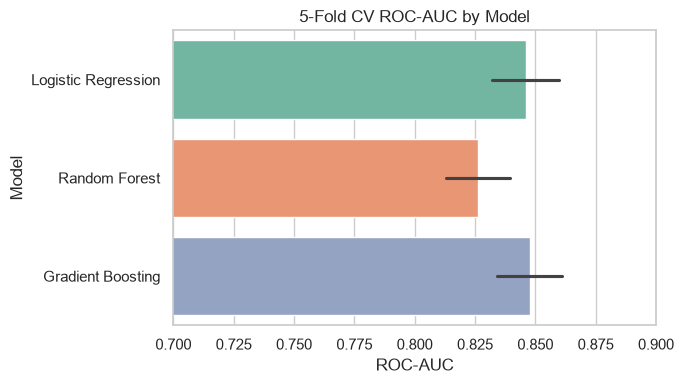

Best model by mean CV ROC-AUC: Gradient Boosting


In [6]:
cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=cv_df.melt(var_name="Model", value_name="ROC-AUC"), x="ROC-AUC", y="Model", hue="Model",
            palette="Set2", legend=False, ax=ax, errorbar="sd")
ax.set_xlim(0.7, 0.9)
ax.set_title("5-Fold CV ROC-AUC by Model")
plt.tight_layout()
plt.show()

best_model_name = cv_df.mean().idxmax()
print("Best model by mean CV ROC-AUC:", best_model_name)

## 6. Hyperparameter Tuning

Randomized search over the best candidate's hyperparameters, still scored on ROC-AUC via the same 5-fold CV split on the training set.

In [7]:
param_grids = {
    "Logistic Regression": {
        "C": np.logspace(-3, 2, 20),
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
    "Random Forest": {
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.7, 0.85, 1.0],
    },
}

base_estimator = candidates[best_model_name]
search = RandomizedSearchCV(
    base_estimator,
    param_distributions=param_grids[best_model_name],
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

best_model = search.best_estimator_

Best params: {'subsample': 0.85, 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.1}
Best CV ROC-AUC: 0.8498


## 7. Final Evaluation on the Held-Out Test Set

In [8]:
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Tuned {best_model_name} — Test Set Performance\n")
print(classification_report(y_test, test_pred, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba):.4f}")

Tuned Gradient Boosting — Test Set Performance

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.8460


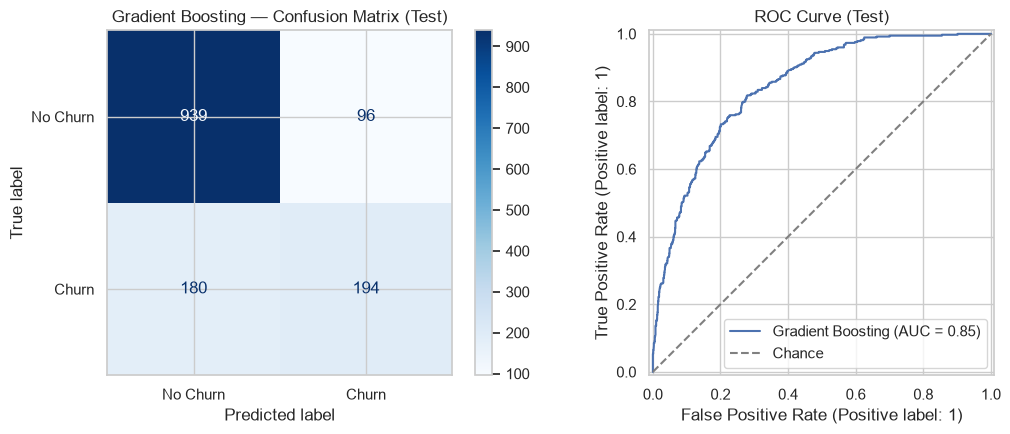

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["No Churn", "Churn"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"{best_model_name} — Confusion Matrix (Test)")

RocCurveDisplay.from_predictions(y_test, test_proba, ax=axes[1], name=best_model_name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[1].set_title("ROC Curve (Test)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance

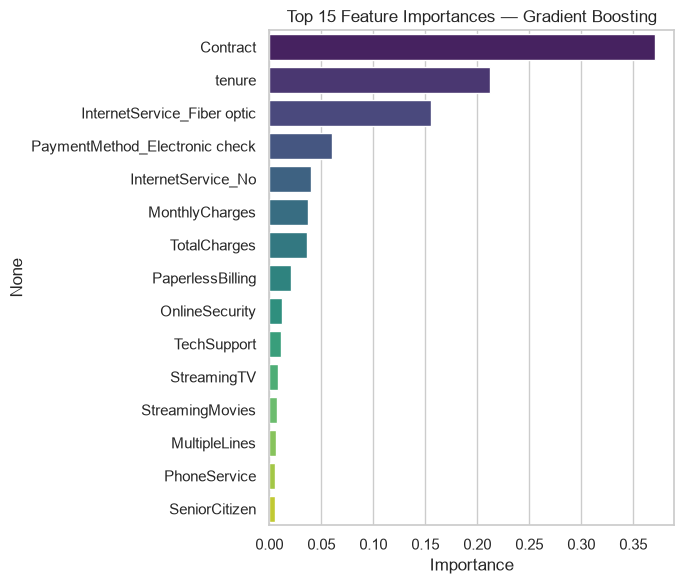

In [10]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X_train.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis",
                legend=False, ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 9. Threshold Tuning for Better Recall

The tuned Gradient Boosting model doesn't support `class_weight`, so at the default 0.5 threshold it under-catches churners even though its ROC-AUC is competitive. Pick a better threshold using **out-of-fold predictions on the training set** (not the test set, to avoid tuning on the data we evaluate on), then apply that single threshold once at the end.

In [11]:
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)

best_f1_idx = np.argmax(f1_scores[:-1])
threshold_best_f1 = thresholds[best_f1_idx]

recall_target = 0.75
above_target = np.where(recalls[:-1] >= recall_target)[0]
threshold_recall_priority = thresholds[above_target[-1]] if len(above_target) else threshold_best_f1

print(f"Default threshold:            0.50  | OOF F1: {f1_score(y_train, oof_proba >= 0.5):.4f}")
print(f"Best-F1 threshold:            {threshold_best_f1:.3f}  | OOF F1: {f1_scores[best_f1_idx]:.4f}"
      f"  (precision {precisions[best_f1_idx]:.3f}, recall {recalls[best_f1_idx]:.3f})")
print(f"Recall-priority threshold:    {threshold_recall_priority:.3f}  | targets recall >= {recall_target}")

Default threshold:            0.50  | OOF F1: 0.5960
Best-F1 threshold:            0.277  | OOF F1: 0.6386  (precision 0.535, recall 0.793)
Recall-priority threshold:    0.313  | targets recall >= 0.75


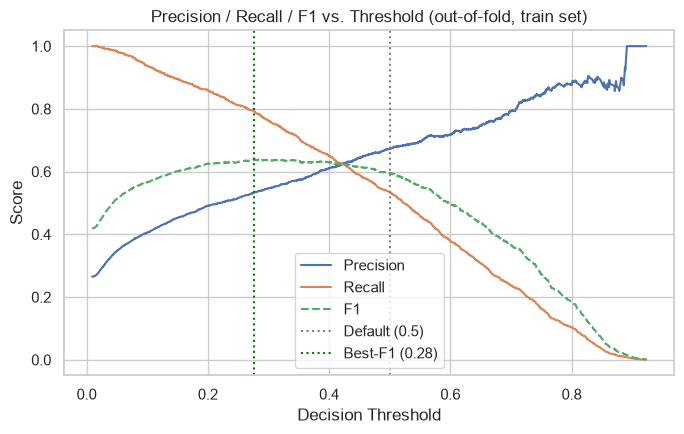


Chosen threshold: 0.277


In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.plot(thresholds, f1_scores[:-1], label="F1", linestyle="--")
ax.axvline(0.5, color="grey", linestyle=":", label="Default (0.5)")
ax.axvline(threshold_best_f1, color="green", linestyle=":", label=f"Best-F1 ({threshold_best_f1:.2f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Threshold (out-of-fold, train set)")
ax.legend()
plt.tight_layout()
plt.show()

chosen_threshold = threshold_best_f1
print(f"\nChosen threshold: {chosen_threshold:.3f}")

## 10. Re-Evaluate Test Set at the Tuned Threshold

Apply `chosen_threshold` (picked on training data only) to the test-set probabilities computed in Step 7, and compare against the default 0.5 cutoff.

In [13]:
test_pred_tuned = (test_proba >= chosen_threshold).astype(int)

print("=== Default threshold (0.50) ===")
print(classification_report(y_test, test_pred, target_names=["No Churn", "Churn"]))

print(f"=== Tuned threshold ({chosen_threshold:.3f}) ===")
print(classification_report(y_test, test_pred_tuned, target_names=["No Churn", "Churn"]))

print("ROC-AUC is unaffected by threshold choice:", round(roc_auc_score(y_test, test_proba), 4))

=== Default threshold (0.50) ===
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409

=== Tuned threshold (0.277) ===
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC is unaffected by threshold choice: 0.846


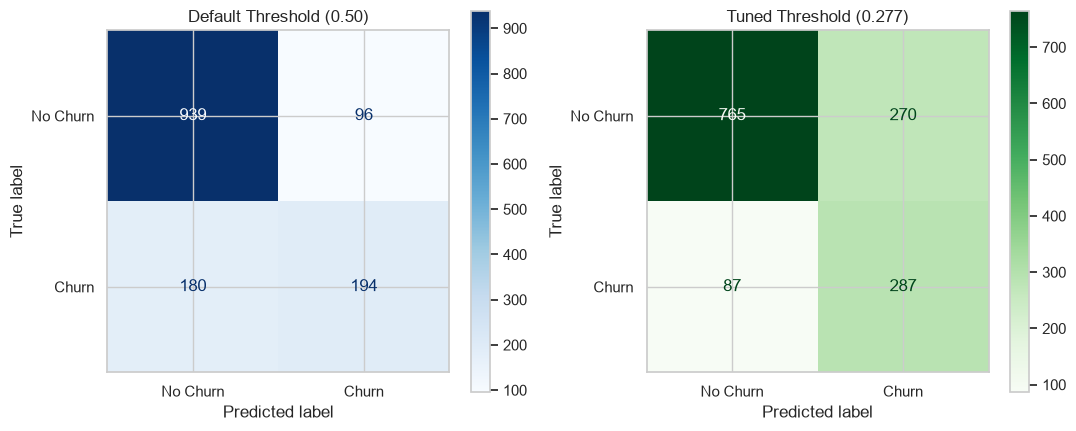

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred, display_labels=["No Churn", "Churn"], cmap="Blues", ax=axes[0]
)
axes[0].set_title("Default Threshold (0.50)")

ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred_tuned, display_labels=["No Churn", "Churn"], cmap="Greens", ax=axes[1]
)
axes[1].set_title(f"Tuned Threshold ({chosen_threshold:.3f})")

plt.tight_layout()
plt.show()

## 11. Save the Trained Model

In [15]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "churn_model.joblib"
joblib.dump(best_model, model_path)

print("Saved model to:", model_path)
print("Model type:", best_model_name)
print("Params:", search.best_params_)

import json

threshold_path = MODELS_DIR / "churn_model_threshold.json"
with open(threshold_path, "w") as f:
    json.dump({"threshold": float(chosen_threshold)}, f)
print("Saved decision threshold to:", threshold_path)

Saved model to: C:\ProjectsOrgnisation-churn-prediction-and-Q-A\models\churn_model.joblib
Model type: Gradient Boosting
Params: {'subsample': 0.85, 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.1}
Saved decision threshold to: C:\ProjectsOrgnisation-churn-prediction-and-Q-A\models\churn_model_threshold.json


## Summary

- Compared Logistic Regression, Random Forest, and Gradient Boosting with 5-fold stratified CV (ROC-AUC) on the training set.
- Tuned the best candidate with `RandomizedSearchCV` (25 iterations, same CV scheme).
- Evaluated once, on the untouched test set, with a classification report, confusion matrix, ROC curve, and feature importances.
- Tuned the decision threshold on **out-of-fold training predictions** (not the test set) to trade some precision for meaningfully better churn recall, then applied it once to the test set.
- Saved the final fitted model to `models/churn_model.joblib` and the chosen threshold to `models/churn_model_threshold.json` (pair both with `models/scaler.joblib` from preprocessing at inference time — score with `predict_proba` and compare against the saved threshold, not `.predict()`).

**Next:** wire this model into `api/` for serving predictions, or, if `xgboost`/`lightgbm` performance is worth chasing, install the `ml` extra (`pip install -e ".[ml]"`) and add them to the candidate comparison.